### **Bloco 1: Instalações e Configurações Iniciais**
Este bloco garante que o ambiente tenha todas as ferramentas para processar texto e grafos.

In [1]:
# 1. Montar o Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Instalar bibliotecas necessárias
!pip install pymupdf spacy networkx nxviz -q

# 3. Baixar o modelo de Português para o spaCy (NER)
!python -m spacy download pt_core_news_lg -q

# 4. Importações essenciais
import fitz  # PyMuPDF
import spacy
import networkx as nx
import pandas as pd
import os
import matplotlib.pyplot as plt

# Carregar o motor de NLP
nlp = spacy.load("pt_core_news_lg")

print("Ambiente configurado com sucesso!")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 19.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 1.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Ambiente configurado com sucesso!


### **Bloco 2: Extração e Limpeza de Texto**
Este bloco define a função que lerá os seus PDFs na pasta do Drive e transformará o conteúdo em texto bruto para o Python.

In [2]:
def extrair_texto_pdf(caminho_arquivo):
    """Extrai texto de um PDF e faz uma limpeza básica."""
    doc = fitz.open(caminho_arquivo)
    texto_completo = ""
    for pagina in doc:
        texto_completo += pagina.get_text()

    # Limpeza básica (remover excesso de espaços e quebras de linha inúteis)
    texto_limpo = " ".join(texto_completo.split())
    return texto_limpo

# Defina o caminho da sua pasta no Drive
caminho_da_pasta = '/content/drive/MyDrive/Projeto_AED2/pdfs/'

# Lista para armazenar o texto de cada TCC
corpus_tccs = []

# Percorrer os arquivos na pasta
for arquivo in os.listdir(caminho_da_pasta):
    if arquivo.endswith(".pdf"):
        caminho_completo = os.path.join(caminho_da_pasta, arquivo)
        print(f"Extraindo texto de: {arquivo}...")
        texto = extrair_texto_pdf(caminho_completo)
        corpus_tccs.append(texto)

print(f"\nTotal de documentos processados: {len(corpus_tccs)}")

Extraindo texto de: EstudoComparativoVariantes_Freire_2025.pdf...
Extraindo texto de: Augusto Damasceno - TCC - Pub.pdf...
Extraindo texto de: UmaAnaliseExploratoria_Bruno_2022.pdf...
Extraindo texto de: CriacaoHardwareSoftware_Oliveira_2021.pdf...
Extraindo texto de: DesenvolvimentoAPIIdentificaçãoFraudePIX_NEVES_2022.pdf...
Extraindo texto de: TCC_Rafael_Souza_final2.pdf...
Extraindo texto de: TCC-Gustavo.pdf...
Extraindo texto de: TCC VICTOR KAILLO - ENG DE COMPUTACAO - UFRN - 23.11.2022-2.pdf...
Extraindo texto de: UmaAnaliseBaseadaemDados_Lima_2023.pdf...
Extraindo texto de: TCC__Renato_Maia_Chacon.pdf...
Extraindo texto de: TCC2023.1 - Rejane Nobre Bezerra.pdf...
Extraindo texto de: UmEstudoSobreFerramentas_Azevedo_2018.pdf...
Extraindo texto de: tcc-ernane-ferreira.pdf...
Extraindo texto de: TCC_Pablio.pdf...
Extraindo texto de: TCC_Gabriel_versao_final.pdf...

Total de documentos processados: 15


In [4]:
# Verificar se há conteúdo no corpus
if corpus_tccs:
    # Selecionar o primeiro TCC (índice 0)
    primeiro_tcc = corpus_tccs[0]

    # Dividir o texto em palavras e pegar as primeiras 200
    palavras = primeiro_tcc.split()
    preview = " ".join(palavras[:200])

    print("-" * 50)
    print("PREVIEW DAS PRIMEIRAS 200 PALAVRAS DO DOCUMENTO 1:")
    print("-" * 50)
    print(preview)
    print("-" * 50)
    print(f"Total de palavras neste documento: {len(palavras)}")
else:
    print("Erro: O corpus está vazio. Verifique o caminho da pasta no Bloco 2.")

--------------------------------------------------
PREVIEW DAS PRIMEIRAS 200 PALAVRAS DO DOCUMENTO 1:
--------------------------------------------------
UNIVERSIDADE DO RIO GRANDE DO NORTE FEDERAL UNIVERSIDADE FEDERAL DO RIO GRANDE DO NORTE CENTRO DE TECNOLOGIA GRADUAÇÃO EM ENGENHARIA DE COMPUTAÇÃO Estudo Comparativo de Variantes de Autoencoders no Algoritmo de Agrupamento Profundo k-Deep Autoencoder Magnus Brigido Paulo Freire Orientador: Prof. Dr. Leonardo Enzo Brito da Silva Natal, RN, 15 de dezembro de 2025 UNIVERSIDADE DO RIO GRANDE DO NORTE FEDERAL UNIVERSIDADE FEDERAL DO RIO GRANDE DO NORTE CENTRO DE TECNOLOGIA GRADUAÇÃO EM ENGENHARIA DE COMPUTAÇÃO Estudo Comparativo de Variantes de Autoencoders no Algoritmo de Agrupamento Profundo k-Deep Autoencoder Magnus Brigido Paulo Freire Orientador: Prof. Dr. Leonardo Enzo Brito da Silva Trabalho de Conclusão de Curso de Gra- duação na modalidade Monografia, subme- tido como parte dos requisitos necessários para conclusão do curso de Enge

### **Bloco 3: Named Entity Recognition (NER)**
Este bloco processa o texto e identifica termos importantes. Como o foco é Engenharia de Computação, vamos filtrar os rótulos que o spaCy identifica como organizações, produtos ou eventos, que geralmente englobam tecnologias e algoritmos.

In [6]:
def extrair_entidades(texto):
    # O spaCy processa o texto (limitamos a 100.000 caracteres por vez para evitar erro de memória)
    doc = nlp(texto[:100000])

    # Lista de categorias que costumam conter termos técnicos
    categorias_alvo = ["ORG", "PRODUCT", "MISC"]

    # Extrair entidades, remover espaços extras e converter para minúsculas para padronizar
    entidades = [ent.text.strip().lower() for ent in doc.ents if ent.label_ in categorias_alvo]

    # Remover termos muito curtos (ruído) ou muito comuns que não são entidades técnicas
    entidades_limpas = [e for e in entidades if len(e) > 2]

    return entidades_limpas

# Testando a extração no primeiro TCC
print("Extraindo entidades (isso pode levar alguns segundos)...")
entidades_exemplo = extrair_entidades(corpus_tccs[0])

print(f"\nTotal de entidades encontradas: {len(entidades_exemplo)}")
print("Alguns exemplos encontrados:", entidades_exemplo[:20])

Extraindo entidades (isso pode levar alguns segundos)...

Total de entidades encontradas: 259
Alguns exemplos encontrados: ['variantes de autoencoders', 'algoritmo de agrupamento profundo k-deep autoencoder', 'variantes de autoencoders', 'algoritmo de agrupamento profundo k-deep autoencoder', 'monografia', 'engenharia de computação', 'divisão de serviços técnicos catalogação da publicação', 'comparativo', 'variantes de autoencoders', 'algoritmo de agrupa- mento', 'centro de tecnologia, curso de engenharia de computação', 'inteligência artificial - monografia', 'aprendizado de máquina', 'autoencoder', 'variantes de autoencoders', 'algoritmo de agrupamento profundo k-deep autoencoder', 'imd', 'imd', 'imd', 'esparso']


### **Bloco 4: Preparação para o Grafo (Janelamento por Sentença)**
Conforme o professor pediu, precisamos analisar diferentes formas de conectar essas entidades. Vamos começar com a Janela de Sentença: se duas tecnologias aparecem na mesma frase, elas ganham uma conexão no grafo.

In [7]:
def gerar_co_ocorrencias_sentenca(texto):
    doc = nlp(texto[:100000])
    pares_conexoes = []

    for sentenca in doc.sents:
        # Extrair entidades apenas desta sentença
        entidades_na_sentenca = [ent.text.strip().lower() for ent in sentenca.ents if len(ent.text) > 2]

        # Criar pares (A, B) entre todas as entidades que aparecem juntas
        for i in range(len(entidades_na_sentenca)):
            for j in range(i + 1, len(entidades_na_sentenca)):
                # Ordenar para evitar duplicatas invertidas como (Python, Java) e (Java, Python)
                par = tuple(sorted([entidades_na_sentenca[i], entidades_na_sentenca[j]]))
                pares_conexoes.append(par)

    return pares_conexoes

print("Gerando conexões por sentença...")
conexoes_sentenca = gerar_co_ocorrencias_sentenca(corpus_tccs[0])
print(f"Total de conexões geradas: {len(conexoes_sentenca)}")

Gerando conexões por sentença...
Total de conexões geradas: 261


### **Bloco 5: Construção do Grafo e Métricas de Centralidade**
Este bloco utiliza o NetworkX para criar o grafo e calcular quem são os "hubs" de conhecimento do seu TCC.

In [8]:
# 1. Criar o objeto de Grafo não direcionado
G_sentenca = nx.Graph()

# 2. Adicionar as conexões e contar a frequência (peso)
for par in conexoes_sentenca:
    u, v = par
    if G_sentenca.has_edge(u, v):
        G_sentenca[u][v]['weight'] += 1
    else:
        G_sentenca.add_edge(u, v, weight=1)

# 3. Calcular métricas de centralidade
grau = nx.degree_centrality(G_sentenca)
intermediacao = nx.betweenness_centrality(G_sentenca)

# 4. Criar um DataFrame para comparar os resultados
df_centralidade = pd.DataFrame({
    'Entidade': list(grau.keys()),
    'Grau (Importância Direta)': list(grau.values()),
    'Intermediação (Ponte)': list(intermediacao.values())
}).sort_values(by='Grau (Importância Direta)', ascending=False)

print("Top 10 Entidades mais centrais por Grau:")
print(df_centralidade.head(10))

Top 10 Entidades mais centrais por Grau:
                     Entidade  Grau (Importância Direta)  \
67                     bishop                   0.121429   
27                        dae                   0.085714   
58                    k-means                   0.078571   
30                        sae                   0.071429   
57                 opochinsky                   0.071429   
10                       ufrn                   0.064286   
15                comparativo                   0.064286   
51                     murphy                   0.064286   
1   variantes de autoencoders                   0.064286   
28                  denoising                   0.057143   

    Intermediação (Ponte)  
67               0.145015  
27               0.053854  
58               0.184652  
30               0.025591  
57               0.053649  
10               0.004265  
15               0.094656  
51               0.065639  
1                0.047174  
28               0

### **Bloco 6: Visualização Exploratória**
Este bloco gera a figura ilustrativa obrigatória para o seu repositório. Vamos usar o spring_layout para organizar a rede.

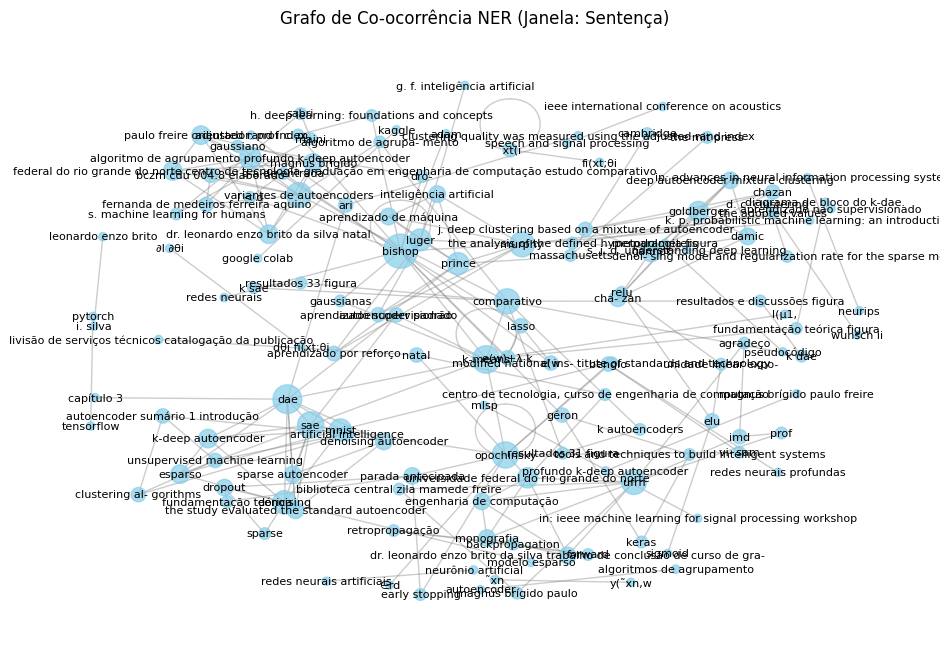

In [9]:
plt.figure(figsize=(12, 8))

# Definir o layout (posicionamento dos nós)
pos = nx.spring_layout(G_sentenca, k=0.5, seed=42)

# O tamanho do nó será proporcional ao seu Grau
tamanhos = [v * 5000 for v in grau.values()]

# Desenhar a rede
nx.draw_networkx_nodes(G_sentenca, pos, node_size=tamanhos, node_color="skyblue", alpha=0.7)
nx.draw_networkx_edges(G_sentenca, pos, width=1, edge_color="gray", alpha=0.4)
nx.draw_networkx_labels(G_sentenca, pos, font_size=8, font_family="sans-serif")

plt.title("Grafo de Co-ocorrência NER (Janela: Sentença)")
plt.axis('off')
plt.show()

### **Bloco 7: Análise de Desempenho (Janela: Parágrafo)**
Agora, para cumprir o requisito de análise de desempenho, vamos criar o grafo usando o parágrafo como unidade de conexão. Espera-se que este grafo seja muito mais denso (mais arestas), pois o parágrafo oferece uma janela maior de co-ocorrência.

In [11]:
def gerar_co_ocorrencias_paragrafo(texto):
    # No nosso leitor de PDF, os parágrafos costumam ser separados por espaços duplos ou padrões de quebra
    # Vamos simular a quebra de parágrafo por blocos de texto maiores
    paragrafos = texto.split(" . ") # Aproximação baseada na extração anterior
    pares_conexoes = []

    for para in paragrafos:
        if len(para) > 50: # Ignorar blocos muito pequenos
            doc_para = nlp(para[:5000])
            entidades_para = [ent.text.strip().lower() for ent in doc_para.ents if len(ent.text) > 2]

            for i in range(len(entidades_para)):
                for j in range(i + 1, len(entidades_para)):
                    par = tuple(sorted([entidades_para[i], entidades_para[j]]))
                    pares_conexoes.append(par)

    return pares_conexoes

print("Gerando conexões por parágrafo...")
conexoes_paragrafo = gerar_co_ocorrencias_paragrafo(corpus_tccs[0])

# Criar Grafo de Parágrafos
G_paragrafo = nx.Graph()
for u, v in conexoes_paragrafo:
    if G_paragrafo.has_edge(u, v):
        G_paragrafo[u][v]['weight'] += 1
    else:
        G_paragrafo.add_edge(u, v, weight=1)

print(f"Total de conexões (Sentença): {len(conexoes_sentenca)}")
print(f"Total de conexões (Parágrafo): {len(conexoes_paragrafo)}")

Gerando conexões por parágrafo...
Total de conexões (Sentença): 261
Total de conexões (Parágrafo): 1984


### **Bloco 8: Análise de Desempenho (Janela: K-Caracteres)**
Diferente das divisões gramaticais, aqui usamos uma "janela deslizante". Se duas entidades aparecem dentro de um intervalo de, por exemplo, 500 caracteres, elas são conectadas.

In [12]:
def gerar_co_ocorrencias_k_caracteres(texto, k=500):
    pares_conexoes = []
    # Processar o texto com spaCy para pegar as posições das entidades
    doc = nlp(texto[:100000])
    entidades_info = [(ent.text.strip().lower(), ent.start_char) for ent in doc.ents if len(ent.text) > 2]

    for i in range(len(entidades_info)):
        for j in range(i + 1, len(entidades_info)):
            ent1, pos1 = entidades_info[i]
            ent2, pos2 = entidades_info[j]

            # Se a distância entre o início de uma e o início da outra for menor que K
            if abs(pos1 - pos2) <= k:
                par = tuple(sorted([ent1, ent2]))
                pares_conexoes.append(par)

    return pares_conexoes

print(f"Gerando conexões por janela de 500 caracteres...")
conexoes_k = gerar_co_ocorrencias_k_caracteres(corpus_tccs[0], k=500)

print(f"Total de conexões (Sentença): {len(conexoes_sentenca)}")
print(f"Total de conexões (Parágrafo): {len(conexoes_paragrafo)}")
print(f"Total de conexões (K-caracteres): {len(conexoes_k)}")

Gerando conexões por janela de 500 caracteres...
Total de conexões (Sentença): 261
Total de conexões (Parágrafo): 1984
Total de conexões (K-caracteres): 2312


### **Bloco 9: Tabela Comparativa de Métricas**
Este bloco calcula a Densidade e o Diâmetro para cada método.

In [13]:
def calcular_metricas_grafo(pares, nome):
    G = nx.Graph()
    G.add_edges_from(pares)
    return {
        "Método": nome,
        "Nós": G.number_of_nodes(),
        "Arestas": G.number_of_edges(),
        "Densidade": f"{nx.density(G):.4f}",
        "Cluster. Médio": f"{nx.average_clustering(G):.4f}"
    }

resultados = [
    calcular_metricas_grafo(conexoes_sentenca, "Sentença"),
    calcular_metricas_grafo(conexoes_paragrafo, "Parágrafo"),
    calcular_metricas_grafo(conexoes_k, "K-caracteres (500)")
]

df_comparativo = pd.DataFrame(resultados)
print("\nTABELA COMPARATIVA DE DESEMPENHO:")
print(df_comparativo)


TABELA COMPARATIVA DE DESEMPENHO:
               Método  Nós  Arestas Densidade Cluster. Médio
0            Sentença  141      210    0.0213         0.5663
1           Parágrafo   75     1143    0.4119         0.9737
2  K-caracteres (500)  197     1676    0.0868         0.7391


### **Bloco 10: Comparação Visual dos Três Métodos**
Este bloco gera três subplots. Note como o grafo de "Parágrafo" será muito mais denso e "fechado" do que o de "Sentença".

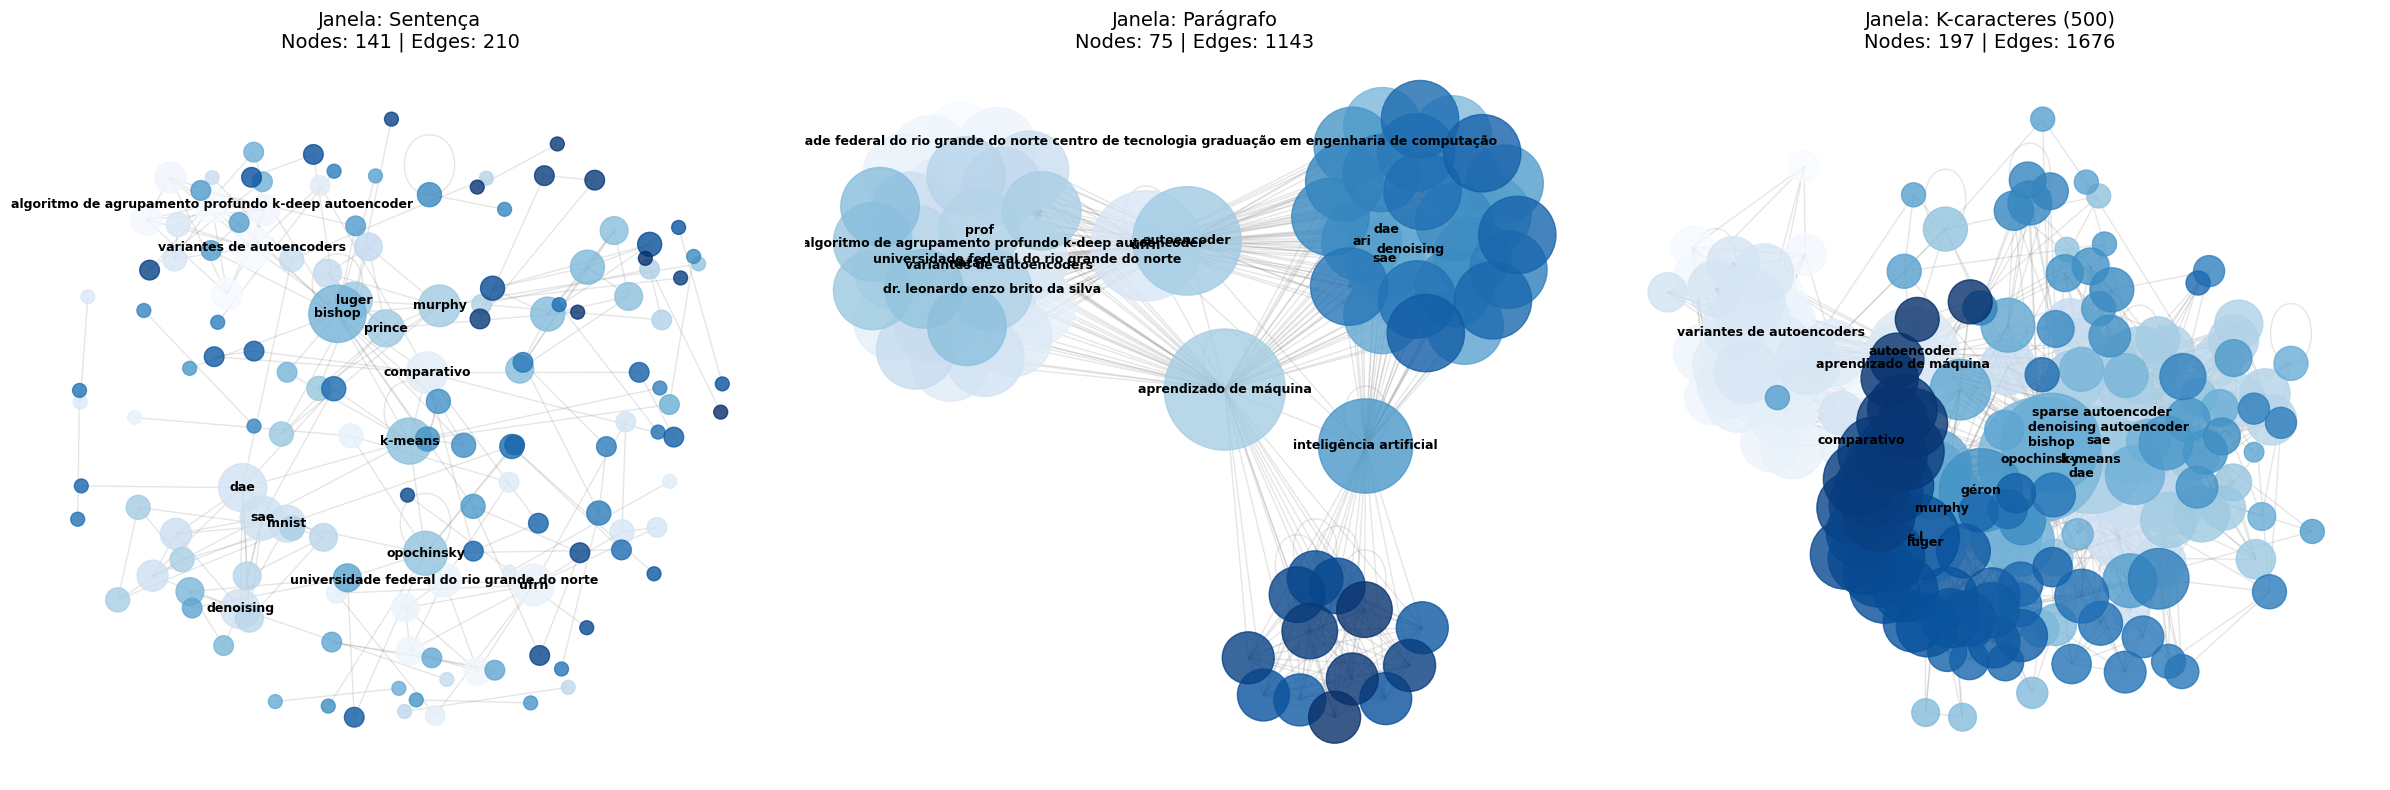

In [14]:
# 1. Garantir que todos os objetos de grafo estejam criados
G_k = nx.Graph()
G_k.add_edges_from(conexoes_k)

grafos = [G_sentenca, G_paragrafo, G_k]
titulos = ["Janela: Sentença", "Janela: Parágrafo", "Janela: K-caracteres (500)"]

# 2. Configurar a figura com 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for i, G in enumerate(grafos):
    ax = axes[i]

    # Calcular métricas para o visual
    d = dict(G.degree())
    pos = nx.spring_layout(G, k=0.5, seed=42)

    # Desenhar arestas com transparência (essencial para grafos densos como o de Parágrafo)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, edge_color='gray')

    # Desenhar nós (tamanho baseado no grau)
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_size=[v * 100 for v in d.values()],
                           node_color=range(len(G)),
                           cmap=plt.cm.Blues, alpha=0.8)

    # Labels apenas para os nós mais importantes (para não poluir a imagem)
    top_nodes = sorted(d, key=d.get, reverse=True)[:15]
    labels = {node: node for node in top_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=9, font_weight='bold')

    ax.set_title(f"{titulos[i]}\nNodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}", fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig("comparacao_metodos_grafos.png", dpi=300) # Salva para usar no README
plt.show()

### **Bloco 11: Consolidação de Conexões (Todos os PDFs)**
Este bloco percorre cada texto na sua lista corpus_tccs, extrai as entidades e acumula as conexões usando os três métodos de janelamento.

In [15]:
# Listas globais para acumular as conexões de todos os documentos
todas_conexoes_sentenca = []
todas_conexoes_paragrafo = []
todas_conexoes_k = []

print(f"Iniciando processamento global de {len(corpus_tccs)} documentos...")

for i, texto in enumerate(corpus_tccs):
    print(f"Processando Documento {i+1}...")

    # Acumular conexões por Sentença
    todas_conexoes_sentenca.extend(gerar_co_ocorrencias_sentenca(texto))

    # Acumular conexões por Parágrafo
    todas_conexoes_paragrafo.extend(gerar_co_ocorrencias_paragrafo(texto))

    # Acumular conexões por K-caracteres
    todas_conexoes_k.extend(gerar_co_ocorrencias_k_caracteres(texto, k=500))

print("\nConsolidação concluída!")
print(f"Total de arestas (Sentença): {len(todas_conexoes_sentenca)}")
print(f"Total de arestas (Parágrafo): {len(todas_conexoes_paragrafo)}")
print(f"Total de arestas (K-caracteres): {len(todas_conexoes_k)}")

Iniciando processamento global de 15 documentos...
Processando Documento 1...
Processando Documento 2...
Processando Documento 3...
Processando Documento 4...
Processando Documento 5...
Processando Documento 6...
Processando Documento 7...
Processando Documento 8...
Processando Documento 9...
Processando Documento 10...
Processando Documento 11...
Processando Documento 12...
Processando Documento 13...
Processando Documento 14...
Processando Documento 15...

Consolidação concluída!
Total de arestas (Sentença): 7903
Total de arestas (Parágrafo): 60554
Total de arestas (K-caracteres): 65696


### **Bloco 12: Geração das Métricas Globais e Tabela Comparativa**
Agora criamos os grafos a partir das listas acumuladas e geramos a tabela de desempenho.

In [17]:
# Função para criar o grafo e calcular métricas (reutilizando a lógica do Bloco 9)
resultados_globais = [
    calcular_metricas_grafo(todas_conexoes_sentenca, "Global: Sentença"),
    calcular_metricas_grafo(todas_conexoes_paragrafo, "Global: Parágrafo"),
    calcular_metricas_grafo(todas_conexoes_k, "Global: K-caracteres")
]

df_global = pd.DataFrame(resultados_globais)
print("TABELA COMPARATIVA GLOBAL (N TRABALHOS):")
print(df_global)

# Identificar os Top 10 Hubs da rede Global (usando Sentença como referência)
G_global_final = nx.Graph()
G_global_final.add_edges_from(todas_conexoes_sentenca)
grau_global = nx.degree_centrality(G_global_final)

df_hubs = pd.DataFrame({
    'Tecnologia/Entidade': list(grau_global.keys()),
    'Centralidade de Grau': list(grau_global.values())
}).sort_values(by='Centralidade de Grau', ascending=False)

print("\nTOP 10 TERMOS MAIS INFLUENTES NO CURSO:")
print(df_hubs.head(10))

TABELA COMPARATIVA GLOBAL (N TRABALHOS):
                 Método   Nós  Arestas Densidade Cluster. Médio
0      Global: Sentença  3169     6380    0.0013         0.5540
1     Global: Parágrafo  1380    32436    0.0341         0.9046
2  Global: K-caracteres  4727    47146    0.0042         0.7250

TOP 10 TERMOS MAIS INFLUENTES NO CURSO:
                              Tecnologia/Entidade  Centralidade de Grau
182                                        figura              0.055871
10                                           ufrn              0.022727
353                                        python              0.018308
1082                                       brasil              0.016730
163                                           rag              0.016730
161                                          llms              0.016730
1305                                    streamlit              0.015783
9     universidade federal do rio grande do norte              0.013889
310           

### **Bloco 13: Visualização da Rede de Conhecimento do Curso**
Este bloco gera o grafo final. Como a rede global terá muito mais nós e arestas, ajustamos a transparência e o tamanho para garantir a clareza visual.

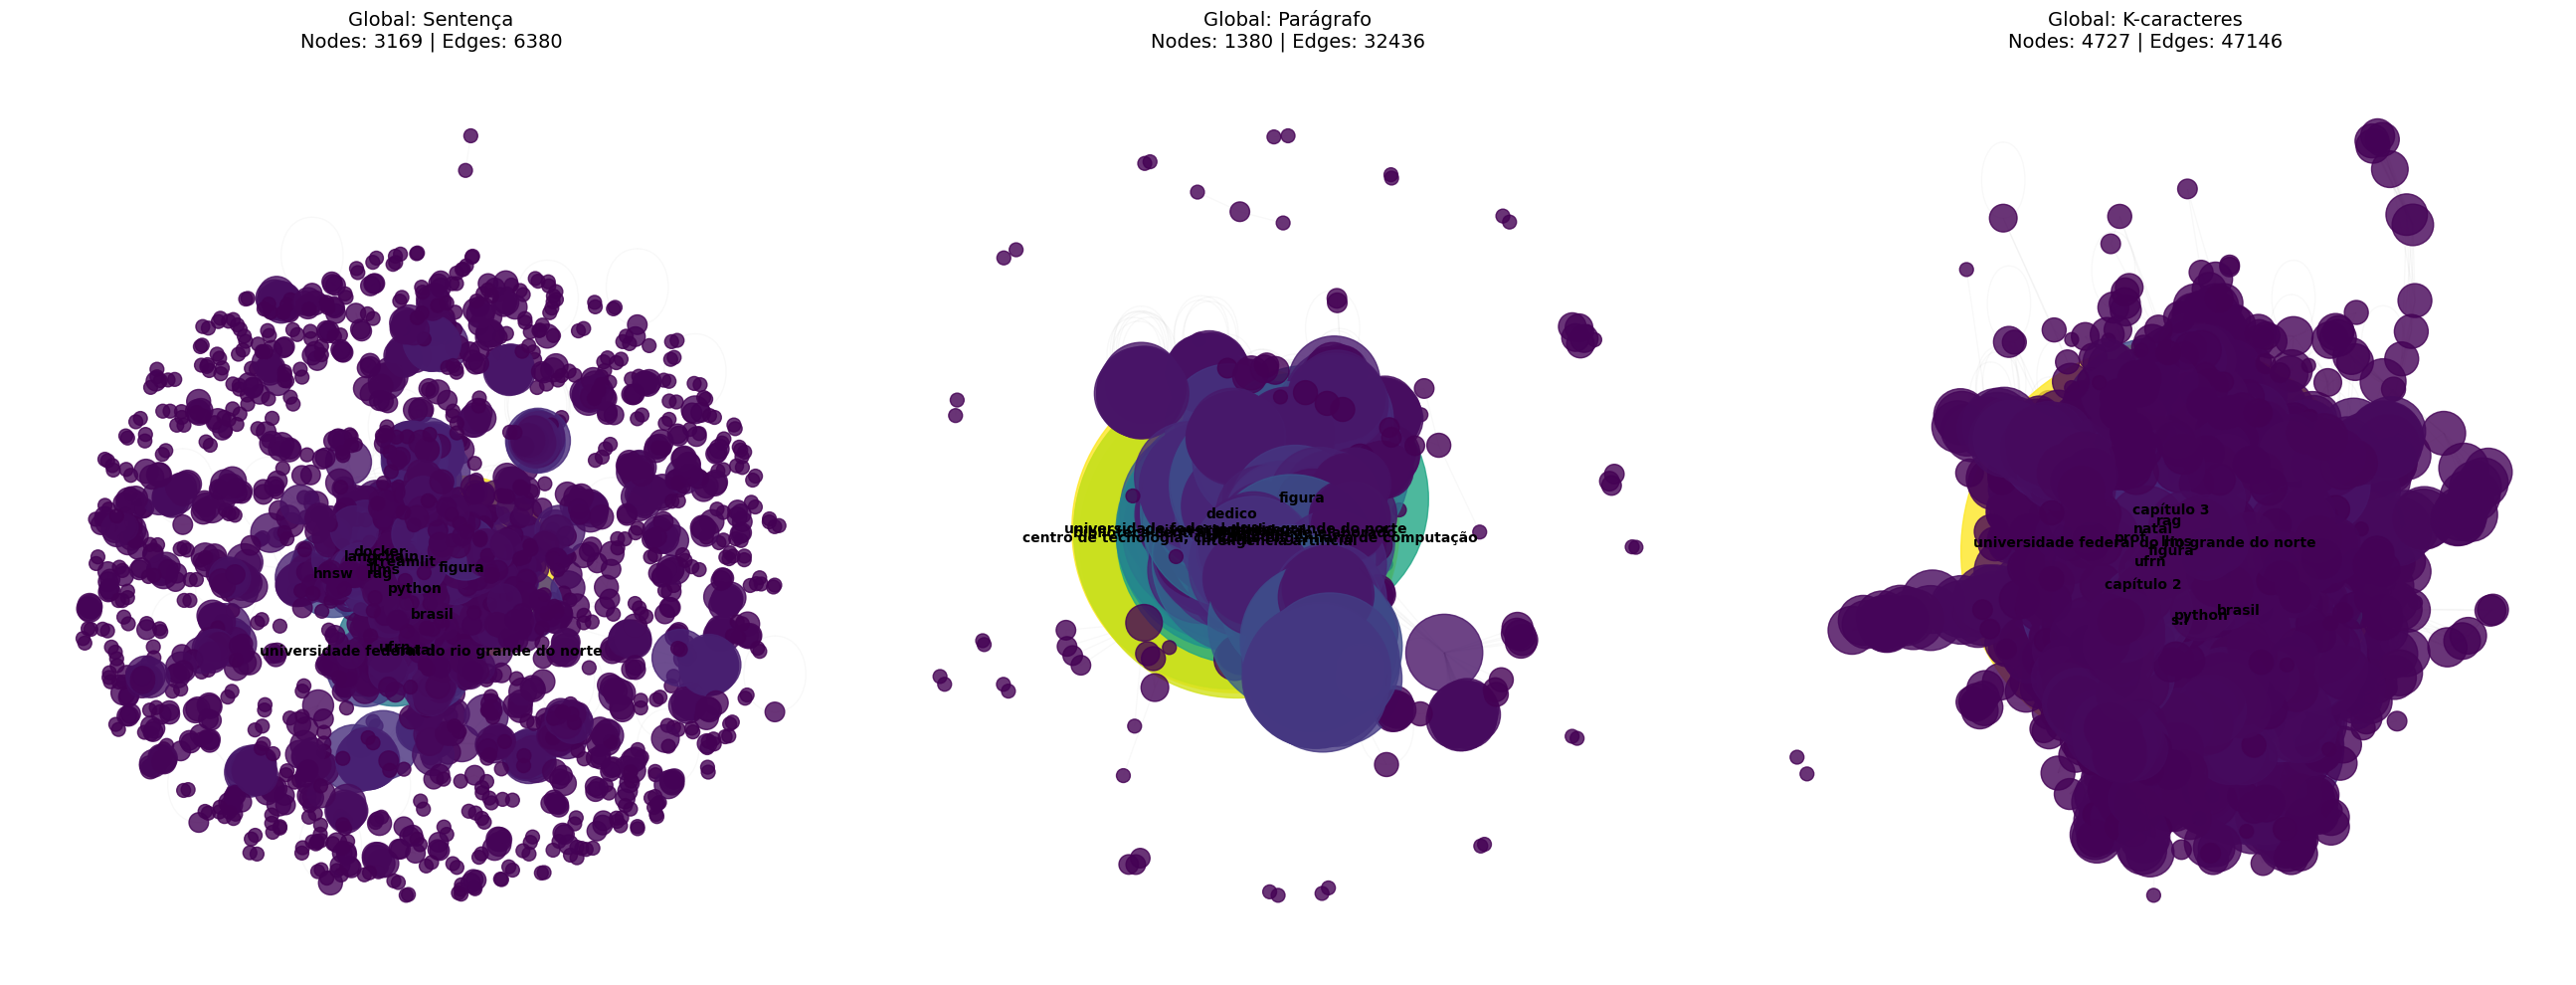

In [18]:
# 1. Criar os objetos de grafo globais
G_global_sentenca = nx.Graph()
G_global_sentenca.add_edges_from(todas_conexoes_sentenca)

G_global_paragrafo = nx.Graph()
G_global_paragrafo.add_edges_from(todas_conexoes_paragrafo)

G_global_k = nx.Graph()
G_global_k.add_edges_from(todas_conexoes_k)

grafos_globais = [G_global_sentenca, G_global_paragrafo, G_global_k]
titulos_globais = ["Global: Sentença", "Global: Parágrafo", "Global: K-caracteres"]

# 2. Configurar a figura para 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(26, 10))

for i, G in enumerate(grafos_globais):
    ax = axes[i]

    # Layout e Métricas para o visual
    d = dict(G.degree())
    pos = nx.spring_layout(G, k=0.5, seed=42)

    # Desenhar arestas (alpha muito baixo para os grafos globais que são densos)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.05, edge_color='gray')

    # Desenhar nós (tamanho proporcional ao grau global)
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_size=[v * 100 for v in d.values()],
                           node_color=list(d.values()),
                           cmap=plt.cm.viridis, alpha=0.8)

    # Labels: Mostrar apenas o Top 12 de cada método para não poluir
    top_nodes = sorted(d, key=d.get, reverse=True)[:12]
    labels = {node: node for node in top_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=10, font_weight='bold')

    ax.set_title(f"{titulos_globais[i]}\nNodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}", fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig("comparacao_global_metodos.png", dpi=300)
plt.show()